# **02_Model_Comparison: Baseline Model Evaluation**

This notebook compares the performance of the trained **baseline models** for phishing detection.

**Main steps:**
1. **Model Loading**
   - Load all trained baseline models

2. **Cross-Validation Performance Comparison**
   - Compare models using `best_score_` from cross-validation

3. **Metric-Based Evaluation**
   - Evaluate **Precision**, **Recall**, **F1-score**, and **ROC-AU**C
   - Compare strengths and weaknesses across models

4. **Confusion Matrix Analysis**
   - Analyze classification behavior for each model
   - Inspect **false positives (FP)** and **false negatives (FN)**

5. **Model Stability Assessment**
   - Compare cross-validation variability using `std_test_score_`

6. **Best Model Selection**
   - Select the most suitable model for downstream fine-tuning and validation

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

from joblib import load
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

---

# **Model Loading**

Load the trained models and the preprocessed test set (`X_test`, `y_test`) for evaluation and comparison.

In [ ]:
rf_search = load("../models/search/random_forest_random_search.joblib")
gb_search = load("../models/search/gradient_boosting_random_search.joblib")
lr_search = load("../models/search/logistic_regression_grid_search.joblib")

X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

---

# **Cross-Validation Performance Comparison**

Check each model's cross-validation `best_score_` to get an initial sense of training performance.

In [3]:
print(rf_search.best_score_)
print(gb_search.best_score_)
print(lr_search.best_score_)

0.9568951271170567
0.9530988137504426
0.904266938210276


---

# **Metric-Based Evaluation**

Extract the `best_estimator_` for each model and generate predictions (`y_pred` and `y_proba`) on the test set.

In [4]:
rf_best = rf_search.best_estimator_
gb_best = gb_search.best_estimator_
lr_best = lr_search.best_estimator_

In [6]:
y_pred_rf = rf_best.predict(X_test)
y_pred_gb = gb_best.predict(X_test)
y_pred_lr = lr_best.predict(X_test)

y_proba_rf = rf_best.predict_proba(X_test)[:, 1]
y_proba_gb = gb_best.predict_proba(X_test)[:, 1]
y_proba_lr = lr_best.predict_proba(X_test)[:, 1]

In [37]:
models = {
    "Random Forest": {
        "search": rf_search,
        "y_pred": y_pred_rf,
        "y_proba": y_proba_rf
    },
    "Gradient Boosting": {
        "search": gb_search,
        "y_pred": y_pred_gb,
        "y_proba": y_proba_gb
    },
    "Logistic Regression": {
        "search": lr_search,
        "y_pred": y_pred_lr,
        "y_proba": y_proba_lr
    }
}

Compute key evaluation metrics for each model using the test set:

- **Precision** : Measures how many predicted phishing sites are actually phishing.
- **Recall** : Measures how many actual phishing sites were correctly identified.
- **F1-score** : Harmonic mean of precision and recall, balancing both metrics.
- **ROC-AUC** : Area under the ROC curve, indicating overall model discrimination.

Store the results in a dictionary and display them in a table for easy comparison.

In [39]:
score_results = {}

for name, data in models.items():
    y_pred = data["y_pred"]
    y_proba = data["y_proba"]

    score_results[name] = {
        "Precision": precision_score(y_test, y_pred, pos_label=1),
        "Recall": recall_score(y_test, y_pred, pos_label=1),
        "F1": f1_score(y_test, y_pred, pos_label=1),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }

In [55]:
pd.DataFrame(score_results).T

,Precision,Recall,F1,ROC-AUC
Random Forest,0.955971,0.959869,0.957916,0.995435
Gradient Boosting,0.950481,0.951876,0.951178,0.994440
Logistic Regression,0.887603,0.913377,0.900306,0.978570


---

# **Confusion Matrix Analysis**

Plot the **confusion matrix** for each model to understand how predictions compare to the true labels.

The confusion matrix shows the number of **true positives, true negatives, false positives, and false negatives** for each model. Optionally, the figures can be saved to disk for reporting or documentation purposes.

In [ ]:
def plot_confusion_matrix(y_pred, filename, title="Confusion Matrix", save=False):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Legitimate", "Phishing"]
    )

    disp.plot(cmap="Blues")
    disp.ax_.set_title(title)

    if save:
        plt.savefig(os.path.join("../figures/confusion_matrix", f"{filename}_confusion_matrix.png"), dpi=300, bbox_inches="tight")

    plt.show()
    plt.close()

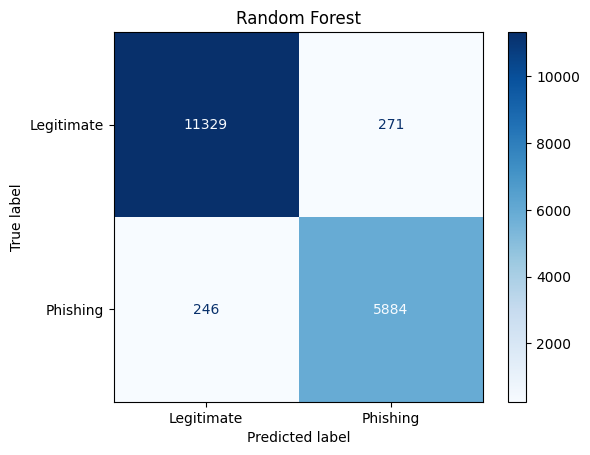

In [ ]:
plot_confusion_matrix(y_pred_rf, title="Random Forest", filename="random_forest")

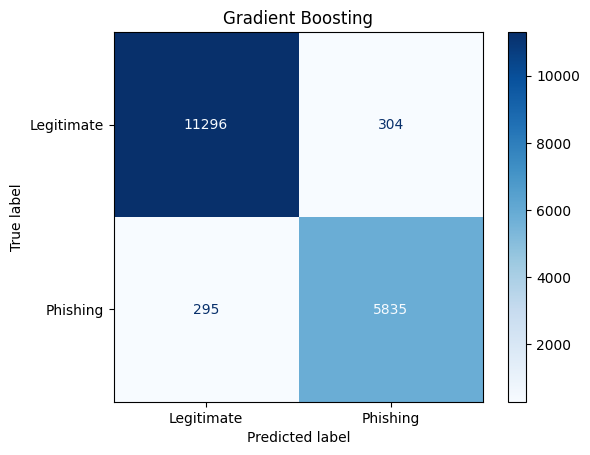

In [ ]:
plot_confusion_matrix(y_pred_gb, title="Gradient Boosting", filename="gradient_boosting")

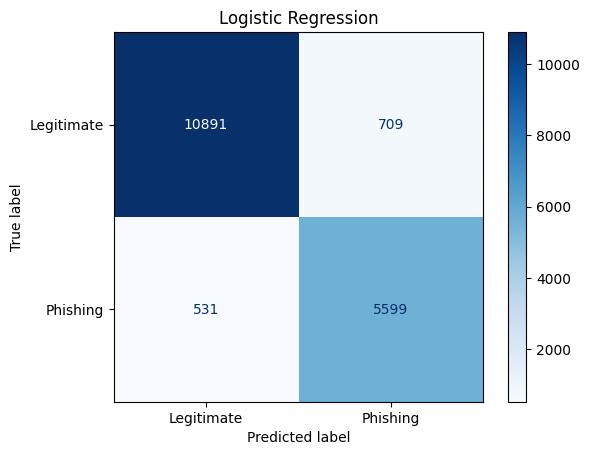

In [ ]:
plot_confusion_matrix(y_pred_lr, title="Logistic Regression", filename="logistic_regression")

---

# **Model Stability Assessment**

Evaluate the **cross-validation standard deviation** (`std_test_score`) for each model to assess stability and consistency during training:

- Lower values indicate more consistent performance across folds.
- Higher values may suggest that the model is sensitive to the training data split.

Display the results in a table for easy comparison among models.

In [43]:
stability_results = {}

for name, data in models.items():
    search = data["search"]
    cv_std = search.cv_results_['std_test_score'][search.best_index_]
    stability_results[name] = {"CV Std": cv_std}

In [57]:
pd.DataFrame(stability_results).T

,CV Std
Random Forest,0.003008
Gradient Boosting,0.003196
Logistic Regression,0.003916


---

# **Best Model Selection**

The evaluation of the three baseline models shows the following:

- **Random Forest** and **Gradient Boosting** achieved very close performance across all metrics:
  - F1-scores: 0.9579 (RF) vs 0.9512 (GB)  
  - ROC-AUC: 0.9954 (RF) vs 0.9944 (GB)  
  - Cross-validation best scores: 0.9569 (RF) vs 0.9531 (GB)  
  - CV standard deviation: 0.0030 (RF) vs 0.0032 (GB)  
- **Random Forest** slightly outperformed Gradient Boosting across all aspects and is more stable.
- **Logistic Regression** showed lower performance on all metrics:
  - F1-score: 0.9003  
  - ROC-AUC: 0.9786  
  - CV best score: 0.9043  
  - CV standard deviation: 0.0039  

**Conclusion:** Random Forest is selected as the best baseline model for further fine-tuning and evaluation due to its slightly superior performance and stability.